# Molecular Physics: Potential Energy Curve Interpolation

Interpolate a sparse Morse potential energy curve with quantum Gaussian-process regression and quantum kernel ridge regression.

## Problem, Variables, and Quantum Advantage Context

**Physics problem.** Recover a smooth potential-energy curve from sparse noisy samples.

**Explicit variables.** `r_train_raw` and `r_test_raw` are bond lengths, `y_train_raw` is noisy energy data, and `gpr_energy` is the quantum-GPR interpolation.

**Quantum advantage context.** Quantum kernels provide nonlinear covariance functions for smooth scientific interpolation. The notebook compares against classical ridge regression.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if repo_root.name == "real_examples":
    repo_root = repo_root.parents[1]
elif repo_root.name == "notebooks":
    repo_root = repo_root.parent

package_root = repo_root / "src"
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from qml import (
    QuantumGaussianProcessRegressor,
    QuantumKernel,
    QuantumKernelClassifier,
    QuantumKernelPCA,
    QuantumKernelRegressor,
    QuantumOneClassClassifier,
    QuantumReservoirClassifier,
    QuantumReservoirFeatures,
    QuantumReservoirRegressor,
    TrainableQuantumKernelRegressor,
)
from qml.reporting import print_section


## Domain simulator

The notebook uses a Morse potential as a compact molecular-physics surrogate and samples sparse noisy training energies.

In [2]:
def morse_potential(r, *, dissociation=4.75, width=1.15, equilibrium=1.4):
    return dissociation * (1.0 - np.exp(-width * (r - equilibrium))) ** 2 - dissociation

rng = np.random.default_rng(501)
r_all = np.linspace(0.75, 2.75, 42)
energy_clean = morse_potential(r_all)
train_idx = np.sort(rng.choice(np.arange(len(r_all)), size=18, replace=False))
test_idx = np.asarray([i for i in range(len(r_all)) if i not in set(train_idx)])

r_train_raw = r_all[train_idx]
r_test_raw = r_all[test_idx]
y_train_raw = morse_potential(r_train_raw) + rng.normal(0.0, 0.025, size=len(r_train_raw))
y_test_raw = morse_potential(r_test_raw)

x_train_raw = np.column_stack([r_train_raw, r_train_raw**2])
x_test_raw = np.column_stack([r_test_raw, r_test_raw**2])
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train_raw)
x_test = scaler.transform(x_test_raw)

y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train_raw.reshape(-1, 1)).ravel()
y_test = y_scaler.transform(y_test_raw.reshape(-1, 1)).ravel()

print_section(
    "Dataset",
    [
        ("Problem", "Morse potential interpolation"),
        ("Training points", int(len(r_train_raw))),
        ("Held-out points", int(len(r_test_raw))),
        ("Features", ["bond length r", "r^2"]),
        ("Target", "potential energy"),
    ],
)


Dataset
+-----------------+-------------------------------+
| Metric          | Value                         |
+-----------------+-------------------------------+
| Problem         | Morse potential interpolation |
| Training points | 18                            |
| Held-out points | 24                            |
| Features        | [bond length r, r^2]          |
| Target          | potential energy              |
+-----------------+-------------------------------+



## System visualization

A direct plot of the simulated physical or mathematical system before fitting any machine-learning model.

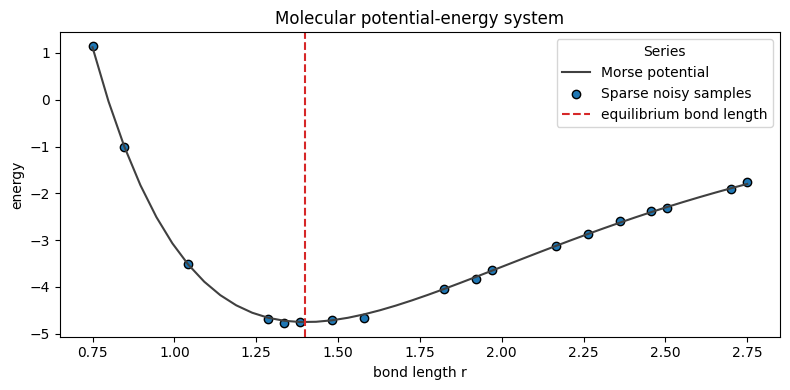

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(r_all, energy_clean, color="0.25", label="Morse potential")
ax.scatter(r_train_raw, y_train_raw, edgecolor="black", label="Sparse noisy samples")
ax.axvline(1.4, linestyle="--", color="tab:red", label="equilibrium bond length")
ax.set_title("Molecular potential-energy system")
ax.set_xlabel("bond length r")
ax.set_ylabel("energy")
ax.legend(title="Series")
plt.tight_layout()
plt.show()


## Package-client interpolation models

In [4]:
qgpr = QuantumGaussianProcessRegressor(QuantumKernel(embedding="iqp", seed=501), alpha=1e-4)
qgpr.fit(x_train, y_train)
gpr_scaled, gpr_std_scaled = qgpr.predict(x_test, return_std=True)
gpr_energy = y_scaler.inverse_transform(gpr_scaled.reshape(-1, 1)).ravel()
gpr_std = gpr_std_scaled * float(y_scaler.scale_[0])

qkr = QuantumKernelRegressor(QuantumKernel(embedding="zz", seed=502), alpha=1e-3)
qkr.fit(x_train, y_train)
qkr_energy = y_scaler.inverse_transform(qkr.predict(x_test).reshape(-1, 1)).ravel()

ridge = Ridge(alpha=1e-2)
ridge.fit(x_train, y_train)
ridge_energy = y_scaler.inverse_transform(ridge.predict(x_test).reshape(-1, 1)).ravel()

results = {
    "quantum_gpr_energy_mae": mean_absolute_error(y_test_raw, gpr_energy),
    "quantum_kernel_ridge_energy_mae": mean_absolute_error(y_test_raw, qkr_energy),
    "ridge_energy_mae": mean_absolute_error(y_test_raw, ridge_energy),
    "quantum_gpr_energy_mse": mean_squared_error(y_test_raw, gpr_energy),
}

print_section(
    "Results",
    [
        ("Quantum GPR energy MAE", results["quantum_gpr_energy_mae"]),
        ("Quantum kernel ridge energy MAE", results["quantum_kernel_ridge_energy_mae"]),
        ("Ridge energy MAE", results["ridge_energy_mae"]),
    ],
)


Results
+---------------------------------+-----------+
| Metric                          | Value     |
+---------------------------------+-----------+
| Quantum GPR energy MAE          | 0.0221625 |
| Quantum kernel ridge energy MAE | 0.073289  |
| Ridge energy MAE                | 0.572759  |
+---------------------------------+-----------+



## Plots

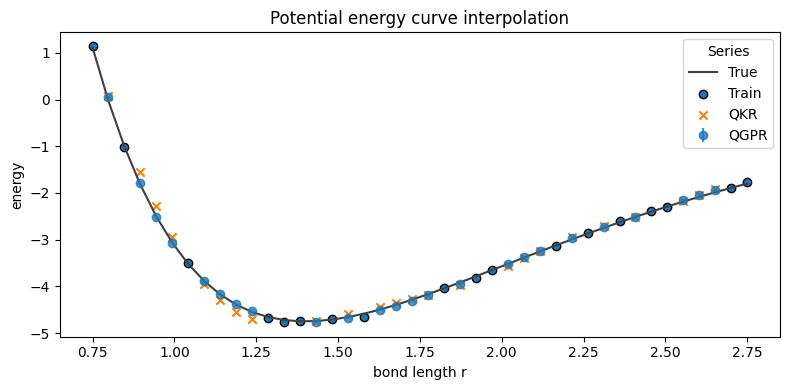

In [5]:
order = np.argsort(r_test_raw)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(r_all, energy_clean, color="0.25", label="True")
ax.scatter(r_train_raw, y_train_raw, label="Train", edgecolor="black")
ax.errorbar(
    r_test_raw[order],
    gpr_energy[order],
    yerr=gpr_std[order],
    fmt="o",
    label="QGPR",
    alpha=0.8,
)
ax.scatter(r_test_raw, qkr_energy, marker="x", label="QKR")
ax.set_title("Potential energy curve interpolation")
ax.set_xlabel("bond length r")
ax.set_ylabel("energy")
ax.legend(title="Series")
plt.tight_layout()
plt.show()


## Validation block

In [6]:
validation = {
    "dataset": {
        "problem": "morse_potential_interpolation",
        "n_train": int(len(r_train_raw)),
        "n_test": int(len(r_test_raw)),
    },
    "results": results,
    "sample_predictions": [
        {"r": float(r), "actual_energy": float(a), "quantum_gpr_energy": float(p)}
        for r, a, p in zip(r_test_raw[:6], y_test_raw[:6], gpr_energy[:6])
    ],
    "passed": bool(
        np.isfinite(gpr_energy).all()
        and np.isfinite(gpr_std).all()
        and results["quantum_gpr_energy_mae"] < 1.5
    ),
}

print("Validation")
print_section("Dataset", validation["dataset"].items())
print_section("Results", validation["results"].items())
print_section("Sample predictions", validation["sample_predictions"][:5])
print_section("Passed", [("passed", validation["passed"])])


Validation
Dataset
+---------+-------------------------------+
| Metric  | Value                         |
+---------+-------------------------------+
| problem | morse_potential_interpolation |
| n_train | 18                            |
| n_test  | 24                            |
+---------+-------------------------------+

Results
+---------------------------------+-------------+
| Metric                          | Value       |
+---------------------------------+-------------+
| quantum_gpr_energy_mae          | 0.0221625   |
| quantum_kernel_ridge_energy_mae | 0.073289    |
| ridge_energy_mae                | 0.572759    |
| quantum_gpr_energy_mse          | 0.000778001 |
+---------------------------------+-------------+

Sample predictions
+----------+---------------+--------------------+
| r        | actual_energy | quantum_gpr_energy |
+----------+---------------+--------------------+
| 0.79878  | -0.0330634    | 0.0471411          |
| 0.896341 | -1.82574      | -1.78565       